In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,recall_score,accuracy_score,precision_score,f1_score


In [32]:
df = pd.read_csv('../data/raw/09-k-means-housing.csv')
df.shape
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


### 1-Limpieza Inicial

In [33]:
df = df.drop(["HouseAge","AveRooms","AveBedrms","Population","AveOccup","MedHouseVal"],axis=1)
df.drop_duplicates(inplace=True)
df.shape


(20635, 3)

### 2-Escalado

In [34]:
scaler = RobustScaler()
scaler_train = scaler.fit_transform(df)
df = pd.DataFrame(scaler_train,columns=df.columns,index=df.index)
df

,MedInc,Latitude,Longitude
0,2.197981,0.957672,-0.986807
1,2.187061,0.952381,-0.984169
2,1.708052,0.949735,-0.989446
3,0.967378,0.949735,-0.992084
4,0.142923,0.949735,-0.992084
...,...,...,...
20635,-0.905896,1.380952,-0.686016
20636,-0.448681,1.383598,-0.717678
20637,-0.841799,1.367725,-0.720317
20638,-0.765084,1.367725,-0.746702


#### Conclusiones

-Utilizamos RobustScaler ya que usa mediana y rango intercuartílico(IQR) lo que hace que sea resistente a outliers

In [35]:
fig = px.scatter_3d(df,
              x="Latitude",
              y="Longitude",
              z="MedInc",
              color="MedInc")
fig.update_layout(
    scene=dict(
        xaxis=dict(showgrid=True, gridcolor="lightgrey", zeroline=True),
        yaxis=dict(showgrid=True, gridcolor="lightgrey", zeroline=True),
        zaxis=dict(showgrid=True, gridcolor="lightgrey", zeroline=True)
    )

)
fig.update_traces(marker=dict(size=3))
fig.show()


### 3-Método del codo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

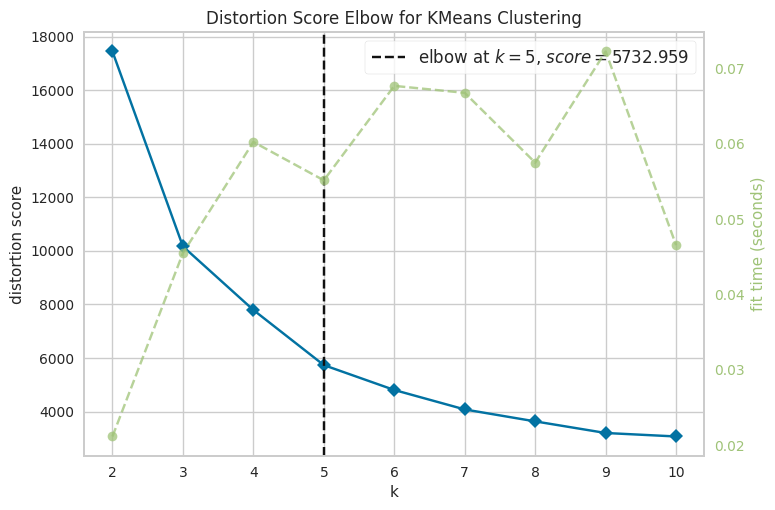

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [36]:
k_means_visual = KMeans(random_state=18)
elbow_visualizer = KElbowVisualizer(k_means_visual, k=(2,11))
elbow_visualizer.fit(df)
elbow_visualizer.show()



### Conclusiones

-Aplicamos el modelo kMeans pero con el objetivo de visualizar  el número optimo de clusters mediante el metodo codo(Elbow Method)
-Cluster: Grupo natural de observaciones similares(Patrones)

### 4-Modelado

In [37]:
k_means = KMeans(n_clusters=5, random_state=18)
df["cluster"] = k_means.fit_predict(df)

df

,MedInc,Latitude,Longitude,cluster
0,2.197981,0.957672,-0.986807,2
1,2.187061,0.952381,-0.984169,2
2,1.708052,0.949735,-0.989446,4
3,0.967378,0.949735,-0.992084,4
4,0.142923,0.949735,-0.992084,1
...,...,...,...,...
20635,-0.905896,1.380952,-0.686016,1
20636,-0.448681,1.383598,-0.717678,1
20637,-0.841799,1.367725,-0.720317,1
20638,-0.765084,1.367725,-0.746702,1


### Conclusiones

-Entrenamos el modelo con los parametros que nos devolvió el metodo del codo anteriormente y obtenemos los cluster(etiquetas) en un solo paso(fit_predict)

### 5-Graficado

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

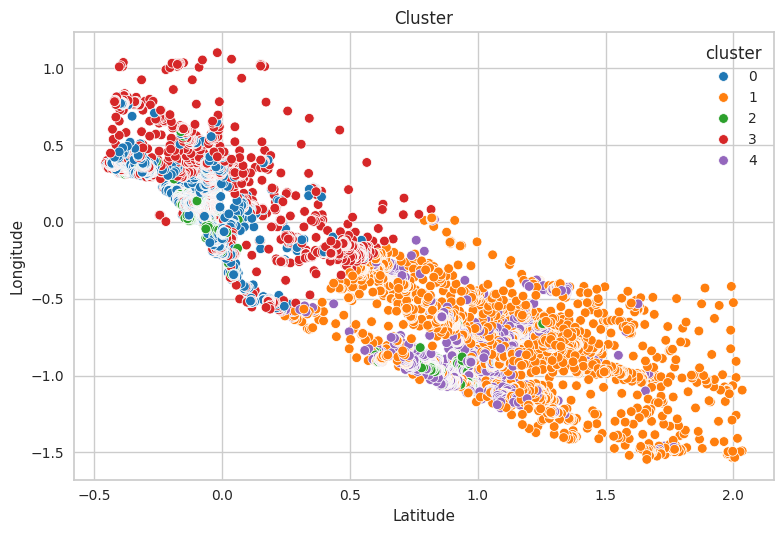

In [38]:
sns.scatterplot(data=df, x="Latitude", y="Longitude", hue="cluster",palette="tab10")
plt.title("Distribucion Geografica")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("Cluster")
plt.tight_layout()
plt.show()

### Conclusiones

-Obtenemos la distribucion de nuestros cluster en relacion a la latitud y longitud

/tmp/ipykernel_1183/2635453571.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='cluster', ylabel='count'>

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

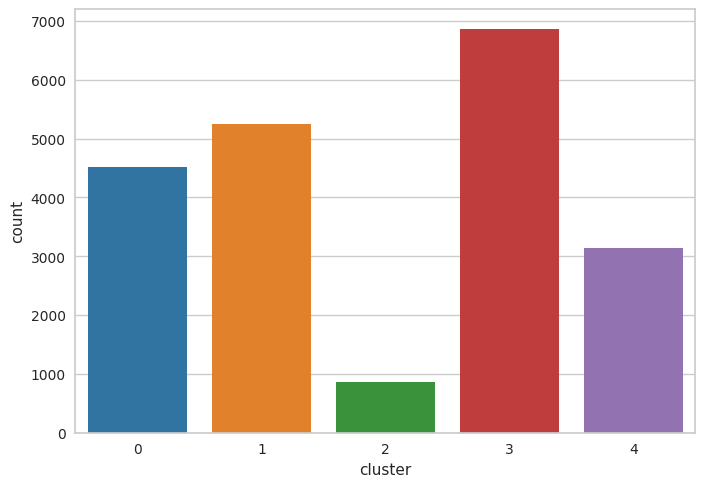

In [39]:
sns.countplot(data=df,x="cluster",palette="tab10")

### 6-Mapeado

In [40]:
ingreso_medio_por_cluster = df.groupby('cluster')['MedInc'].mean().sort_index()
ingreso_medio_por_cluster

cluster
0    0.707620
1   -0.397853
2    2.775766
3   -0.391009
4    0.739093
Name: MedInc, dtype: float64

### Conclusiones

-Indexamos los cluster obtenidos y le asignamos como valor la media de ingresos(valores transofrmados)

In [41]:
ingresos = {0:"Ingresos medios",
            1:"Ingresos bajos",
            2:"Ingresos altos",
            3:"Ingresos bajos",
            4:"Ingresos medios"}
df["Ingresos"] = df["cluster"].map(ingresos)
df

,MedInc,Latitude,Longitude,cluster,Ingresos
0,2.197981,0.957672,-0.986807,2,Ingresos altos
1,2.187061,0.952381,-0.984169,2,Ingresos altos
2,1.708052,0.949735,-0.989446,4,Ingresos medios
3,0.967378,0.949735,-0.992084,4,Ingresos medios
4,0.142923,0.949735,-0.992084,1,Ingresos bajos
...,...,...,...,...,...
20635,-0.905896,1.380952,-0.686016,1,Ingresos bajos
20636,-0.448681,1.383598,-0.717678,1,Ingresos bajos
20637,-0.841799,1.367725,-0.720317,1,Ingresos bajos
20638,-0.765084,1.367725,-0.746702,1,Ingresos bajos


### Conclusiones

-Mapeamos para asignar un valor mas amigable a cada cluster segun los ingresos


### 7-Entrenamiento y objetivo

In [42]:
X = df.drop(["cluster","Ingresos"], axis=1)
y = df["cluster"]

### 8-Split

In [43]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42,stratify=y)
X_train,X_test,y_train,y_test

(         MedInc  Latitude  Longitude
 484   -0.775407  0.952381  -0.997361
 6077   0.447488 -0.042328   0.168865
 14334 -1.040560 -0.407407   0.350923
 15943  0.060564  0.915344  -1.039578
 12703 -0.463501  1.145503  -0.770449
 ...         ...       ...        ...
 16418 -0.266850  0.955026  -0.733509
 14299 -0.650746 -0.410053   0.356201
 8339   0.647717 -0.087302   0.047493
 13679  0.826749 -0.058201   0.329815
 10653  0.602936 -0.182540   0.200528
 
 [16508 rows x 3 columns],
          MedInc  Latitude  Longitude
 8443   0.693049 -0.095238   0.034301
 938    0.278000  0.867725  -0.934037
 14264 -0.679055 -0.415344   0.366755
 7088   0.675843 -0.087302   0.129288
 5585   0.820050 -0.119048   0.050132
 ...         ...       ...        ...
 9896   1.397201  1.066138  -0.994723
 6707   0.156137 -0.031746   0.089710
 5611  -0.637761 -0.124339   0.058047
 6328   1.202340 -0.074074   0.150396
 12792  0.127460  1.161376  -0.783641
 
 [4127 rows x 3 columns],
 484      1
 6077     0
 14334 

### 9-Modelo(Supervisado)

In [44]:
xgbc_optimized = XGBClassifier()
xgbc_optimized.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### 10-Predicción

In [45]:
y_predict_train = xgbc_optimized.predict(X_train)
y_predict_test = xgbc_optimized.predict(X_test)
y_predict_train,y_predict_test

(array([1, 0, 3, ..., 0, 0, 0], shape=(16508,)),
 array([0, 4, 3, ..., 3, 0, 1], shape=(4127,)))

### 11-Obtención de Métricas

In [46]:
def get_classifier_metrics(y_predict_test, y_test, y_predict_train, y_train, average='micro'):
    metrics_train = (accuracy_score(y_train, y_predict_train),
                     f1_score(y_train, y_predict_train, average=average),
                     precision_score(y_train, y_predict_train, average=average),
                     recall_score(y_train, y_predict_train, average=average))
    metrics_test = (accuracy_score(y_test, y_predict_test),
                    f1_score(y_test, y_predict_test, average=average),
                    precision_score(y_test, y_predict_test, average=average),
                    recall_score(y_test, y_predict_test, average=average))
    return pd.DataFrame(data=[metrics_train, metrics_test],
                        columns=['Accuracy', 'F1 Score', 'Precision', 'Recall'],
                        index=['Train set', 'Test set'])

result = get_classifier_metrics(y_predict_test, y_test, y_predict_train, y_train)
result

,Accuracy,F1 Score,Precision,Recall
Train set,0.999879,0.999879,0.999879,0.999879
Test set,0.995396,0.995396,0.995396,0.995396


### Conclusiones

-utilizamos Boosting(XGBClassifier) por su gran precision y capacidad de generalización